In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import re


In [13]:
import kagglehub

# Download latest version
#path = kagglehub.dataset_download("lakshmi25npathi/online-retail-dataset")

#print("Path to dataset files:", path)

C:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
df = pd.read_excel(r"./datasets/online_retail_II.xlsx")


# **hacer un ensuciado de datos**

In [15]:
df_dirty = df.copy()
# 1. AGREGAR VALORES NULOS (10-15% aleatorio)
np.random.seed(42)
null_cols = ['Description', 'Customer ID', 'Country', 'Price', 'Quantity']

for col in null_cols:
    null_idx = np.random.choice(df_dirty.index,
                                size=int(len(df_dirty) * np.random.uniform(0.05, 0.15)),
                                replace=False)
    df_dirty.loc[null_idx, col] = np.nan
# 2. AGREGAR VALORES ATÍPICOS (outliers)
# Cantidades negativas o extremadamente grandes
neg_qty_idx = np.random.choice(df_dirty.index, size=500, replace=False)
df_dirty.loc[neg_qty_idx, 'Quantity'] = -np.random.randint(1, 100, 500)

# Precios extremos (negativos o muy altos)
extreme_price_idx = np.random.choice(df_dirty.index, size=300, replace=False)
df_dirty.loc[extreme_price_idx, 'Price'] = np.random.choice([-10, -50, 9999, 50000, 0.001], 300)
# 3. FORMATOS INCORRECTOS EN FECHAS
df_dirty['InvoiceDate'] = df_dirty['InvoiceDate'].astype('object')
date_idx = np.random.choice(df_dirty.index, size=200, replace=False)
for idx in date_idx:
    # Convertir algunas fechas a string con formato incorrecto
    df_dirty.loc[idx, 'InvoiceDate'] = np.random.choice([
        '2023-13-01',  # mes inválido
        '01/01/23',    # formato diferente
        'invalid_date',
        '2023-02-29',  # fecha inválida
        'Jan 1, 2023'
    ])
# 4. DATOS DUPLICADOS (agregar ~1000 filas duplicadas)
dup_indices = np.random.choice(df_dirty.index, size=1000, replace=True)
df_duplicates = df_dirty.loc[dup_indices].copy()
df_dirty = pd.concat([df_dirty, df_duplicates], ignore_index=True)

# 5. TEXTOS CON ERRORES EN 'Description'
# Minúsculas, mayúsculas, espacios, typos
desc_idx = np.random.choice(df_dirty.index, size=2000, replace=False)
for idx in desc_idx:
    if pd.notna(df_dirty.loc[idx, 'Description']):
        current = str(df_dirty.loc[idx, 'Description'])
        error_type = np.random.choice(['lower', 'upper', 'spaces', 'typo', 'mixed'])

        if error_type == 'lower':
            df_dirty.loc[idx, 'Description'] = current.lower()
        elif error_type == 'upper':
            df_dirty.loc[idx, 'Description'] = current.upper()
        elif error_type == 'spaces':
            df_dirty.loc[idx, 'Description'] = '  ' + current + '   '
        elif error_type == 'typo':
            df_dirty.loc[idx, 'Description'] = current.replace('a', '@').replace('e', '3')
        elif error_type == 'mixed':
            df_dirty.loc[idx, 'Description'] = current[:5].upper() + current[5:].lower()
# 6. ERRORES EN 'Customer ID' (valores no numéricos)
df_dirty['Customer ID'] = df_dirty['Customer ID'].astype('object')

cust_idx = np.random.choice(df_dirty.index, size=500, replace=False)
df_dirty.loc[cust_idx, 'Customer ID'] = np.random.choice(['ABC123', 'N/A', 'unknown', '#N/A', ''], 500)


# 8. PAÍSES CON NOMBRES INCONSISTENTES
df_dirty['Country'] = df_dirty['Country'].astype('object')

country_idx = np.random.choice(df_dirty.index, size=1000, replace=False)
country_variations = {
    'United Kingdom': ['UK', 'U.K.', 'England', 'uk', 'United Kingdom ', 'GB'],
    'USA': ['US', 'U.S.A.', 'America', 'usa', 'United States'],
    'Germany': ['DE', 'Deutschland', 'germany', 'GER'],
    'France': ['FR', 'france', 'FRA', 'Francia']
}

for idx in country_idx:
    if pd.notna(df_dirty.loc[idx, 'Country']):
        country = df_dirty.loc[idx, 'Country']
        for standard, variations in country_variations.items():
            if country == standard:
                df_dirty.loc[idx, 'Country'] = np.random.choice(variations)
                break



# EDA inicial: nulls, duplicados y estadísticas

Exploración rápida de df_dirty para detectar nulos, duplicados, tipos de datos y estadísticas clave.



In [16]:
df_dirty.head(1)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12.0,2009-12-01 07:45:00,6.95,13085.0,United Kingdom


In [17]:
df_dirty.info()

<class 'pandas.DataFrame'>
RangeIndex: 526461 entries, 0 to 526460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      526461 non-null  object 
 1   StockCode    526461 non-null  object 
 2   Description  477728 non-null  object 
 3   Quantity     455275 non-null  float64
 4   InvoiceDate  526461 non-null  object 
 5   Price        488431 non-null  float64
 6   Customer ID  369437 non-null  object 
 7   Country      491712 non-null  object 
dtypes: float64(2), object(6)
memory usage: 32.1+ MB


In [18]:
df_dirty.describe()

,Quantity,Price
count,455275.000000,488431.000000
mean,10.198873,11.861648
std,105.206526,576.071363
min,-9600.000000,-53594.360000
25%,1.000000,1.250000
50%,3.000000,2.100000
75%,10.000000,4.210000
max,19152.000000,50000.000000


In [19]:
pd.DataFrame({
    'nulls': df_dirty.isnull().sum(),
    'unique': df_dirty.duplicated().sum(),
    'shape' :df_dirty.shape[0]
})

,nulls,unique,shape
Invoice,0,3767,526461
StockCode,0,3767,526461
Description,48733,3767,526461
Quantity,71186,3767,526461
InvoiceDate,0,3767,526461
Price,38030,3767,526461
Customer ID,157024,3767,526461
Country,34749,3767,526461


# **SNAKE CASE**

In [20]:
print(type(df_dirty))

<class 'pandas.DataFrame'>


In [24]:
df_dirty.columns = (df_dirty.columns
                    .str.strip()
                    .str.lower()
                    .str.replace(r'\s+', '_', regex=True)
                    .str.replace(r'(?<!^)(?=[A-Z])', '_', regex=True)
                    .str.replace('__', '_', regex=True)
                    .str.strip('_')
                    )


In [28]:
df_dirty.head(1)

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12.0,2009-12-01 07:45:00,6.95,13085.0,United Kingdom


In [31]:
def to_snake(x):
    if isinstance(x, str):
        x = x.strip().lower()
        x = re.sub(r'[^a-z0-9]+', '_', x)  # todo lo raro → _
        x = re.sub(r'_+', '_', x)          # evita ___
        return x.strip('_')               # quita _ al inicio/fin
    return x
df_dirty = df_dirty.apply(lambda col: col.map(to_snake))

In [37]:
df_dirty.head(1)

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country
0,489434,85048,15cm_christmas_glass_ball_20_lights,12.0,2009-12-01 07:45:00,6.95,13085.0,united_kingdom


# Detectamos Valores atipicos Outliers

<Axes: xlabel='variable', ylabel='value'>

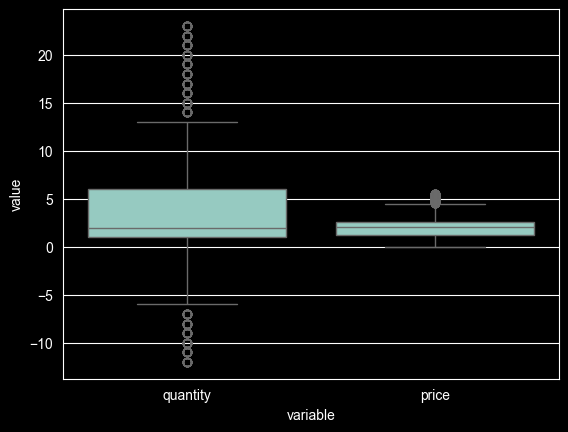

In [61]:
sns.boxplot(
    data=df_dirty.melt(value_vars=['quantity','price']),
    x='variable',
    y='value'
)

In [49]:
from numpy import percentile

outliers={}
for col in df_dirty.select_dtypes(include='number').columns:
  Q1 = df_dirty[col].quantile(0.25)
  Q3 = df_dirty[col].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  mask = (df_dirty[col] < lower) | (df_dirty[col] > upper)

  outliers[col] = df_dirty[(df_dirty[col] < lower) | (df_dirty[col] > upper)][col]

  if col != 'quantity':
      media = df_dirty[col].mean().round()
      df_dirty.loc[mask, col] = df_dirty[col].median()

for i in outliers:
  print(i)



quantity
price


# Limpieza de Datos

In [54]:
df_dirty = df_dirty[df_dirty["customer_id"].notna()]

df_dirty["description"] = df_dirty["description"].fillna("unknown")
df_dirty["country"] = df_dirty["country"].fillna(df_dirty["country"].mode()[0])

df_dirty["price"] = df_dirty["price"].fillna(df_dirty["price"].median())
df_dirty = df_dirty[df_dirty["quantity"].notna()]

df_dirty["invoicedate"] = pd.to_datetime(df_dirty["invoicedate"], errors="coerce")
df_dirty = df_dirty[df_dirty["invoicedate"].notna()]

**verificacion y eliminacion duplicados**


In [58]:
df_dirty.duplicated().sum()

np.int64(0)

In [57]:
df_dirty = df_dirty.drop_duplicates()

In [59]:
pd.DataFrame({
    'nulls': df_dirty.isnull().sum(),
    'unique': df_dirty.duplicated().sum(),
    'shape' :df_dirty.shape[0]
})

,nulls,unique,shape
invoice,0,0,521952
stockcode,0,0,521952
description,0,0,521952
quantity,0,0,521952
invoicedate,0,0,521952
price,0,0,521952
customer_id,0,0,521952
country,0,0,521952


In [60]:
df_dirty.head(1)

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country
0,489434,85048,15cm_christmas_glass_ball_20_lights,12.0,2009-12-01 07:45:00,2.1,13085.0,united_kingdom


In [63]:
df_dirty["country"].unique()

<StringArray>
[      'united_kingdom',               'france',                  'usa',
              'belgium',            'australia',                   'gb',
                 'eire',              'germany',                   'uk',
             'portugal',                  'u_k',                'japan',
              'denmark',              'nigeria',          'netherlands',
               'poland',                'spain',              'england',
      'channel_islands',                'italy',               'cyprus',
               'greece',               'norway',              'austria',
               'sweden', 'united_arab_emirates',              'finland',
          'switzerland',          'unspecified',                'malta',
              'bahrain',                  'rsa',          'deutschland',
              'bermuda',            'hong_kong',                   'de',
            'singapore',                   'fr',              'francia',
             'thailand',             

In [68]:
from utils.valid_countries import normalize_country

df_dirty["country"] = df_dirty["country"].apply(normalize_country)

In [69]:
df_dirty["country"].unique()

<StringArray>
[      'united_kingdom',               'france',                  'usa',
              'belgium',            'australia',              'germany',
              'ireland',             'portugal',                'japan',
              'denmark',              'nigeria',          'netherlands',
          'switzerland',                'spain',              'finland',
                'italy',               'greece',               'norway',
              'austria',               'sweden', 'united_arab_emirates',
              'bahrain',            'hong_kong',          'west_indies',
              'lebanon',                'korea',               'brazil',
               'canada']
Length: 28, dtype: str